## Practice 2: Find out to which person each tweet belongs to

There are three excel files with approx 7000 tweets from Elon Musk, Bill Gates and Ed Lee (former San Francisco major).
The goal is to build a model that finds the author of any of those.
<br>
We will use two approaches: Bag of Words and TF-IDF
<br>
But before, we must do some text preprocessing common in Natural Language Processing pipelines: eliminate short not so useful words, and lemmatization: reduce words to their base form.

In [1]:
import numpy as np
import pandas as pd
import string
import re

import warnings
warnings.filterwarnings('ignore')

In [2]:
elondf=pd.read_excel("https://raw.githubusercontent.com/Navenkumar-Balasubramaniam/00-General/main/19%20Naive%20Bayes/Tweets/ElonMusk.xlsx")
bgatesdf=pd.read_excel("https://raw.githubusercontent.com/Navenkumar-Balasubramaniam/00-General/main/19%20Naive%20Bayes/Tweets/BGates.xlsx")
edleedf=pd.read_excel("https://raw.githubusercontent.com/Navenkumar-Balasubramaniam/00-General/main/19%20Naive%20Bayes/Tweets/EdLee.xlsx")

print('Number of tweets @elonmusk: ' + str(elondf.shape[0]))
print('Number of tweets @BillGates: ' + str(bgatesdf.shape[0]))
print('Number of tweets @mayorEdlee: ' + str(edleedf.shape[0]))

# Merge all tweets into a database
data = pd.concat([elondf, bgatesdf, edleedf], ignore_index=True)

# Selects only interesting columns
data = data[['screen_name', 'created_at', 'status_id', 'text']]
data.columns = ['author', 'date', 'id', 'text']

# Date parsing
data['date'] = pd.to_datetime(data['date'])
data.sample(15)

Number of tweets @elonmusk: 2678
Number of tweets @BillGates: 2087
Number of tweets @mayorEdlee: 2447


,author,date,id,text
1316,elonmusk,2016-04-03 22:02:16+00:00,716747672477151232,@torvos torque is shifted between front &amp; ...
4589,BillGates,2013-06-01 00:01:24+00:00,340619050180829184,This story about the development of the #rotav...
6846,mayoredlee,2016-11-17 22:17:44+00:00,799376000475770880,Urban manufacturing increases #jobs for reside...
6962,mayoredlee,2017-05-22 18:45:44+00:00,866726790894505984,Amsterdam Rainbow Dress is a reminder that man...
4452,BillGates,2015-10-08 15:57:31+00:00,652150840124305408,Malala is a real inspiration. My impressions f...
6722,mayoredlee,2016-03-28 16:16:06+00:00,714486231862644736,Proud of strong community &amp; business suppo...
1257,elonmusk,2017-06-20 05:42:50+00:00,877039014334701440,@sulka @KarinCAtrades Cool
5598,mayoredlee,2017-05-29 19:12:20+00:00,869270200289460224,We partner w/@vetshelpingvets to honor &amp; s...
6917,mayoredlee,2017-04-21 16:25:46+00:00,855457543484723200,Installing speed safety camera technologies wi...
4041,BillGates,2015-06-25 12:25:26+00:00,614046742426845184,A data nerd after my own heart...Man searches ...


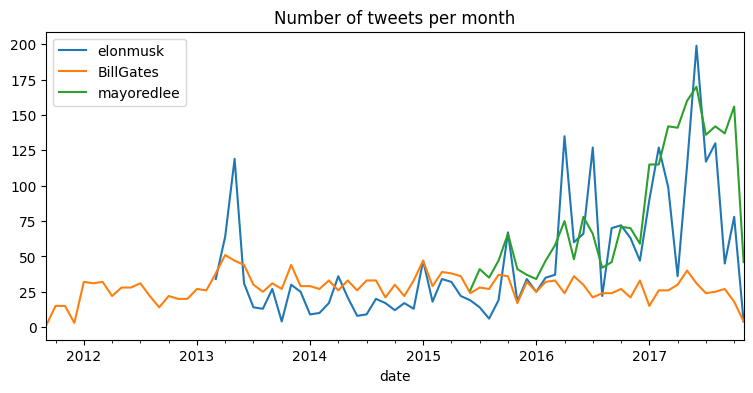

In [3]:
# Optional: temporary distribution of tweets

import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

fig, ax = plt.subplots(figsize=(9,4))

for author in data.author.unique():
    df_temp = data[data['author'] == author].copy()
    df_temp['date'] = pd.to_datetime(df_temp['date'].dt.strftime('%Y-%m'))
    df_temp = df_temp.groupby(df_temp['date']).size()
    df_temp.plot(label=author, ax=ax)

ax.set_title('Number of tweets per month')
ax.legend();

In [4]:
# NLTK: Natural Language Toolkit
#!pip install nltk
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.stem.porter import *
from nltk.tokenize import RegexpTokenizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
# This function does some text cleaning.
def cleantext(text):
    # lowercase
    new_text = text.lower()
    # Removal of web sites (starts with "http")
    new_text = re.sub('http\S+', ' ', new_text)
    # Number removal
    new_text = re.sub("\d+", ' ', new_text)
    # Multiple blank spaces removal
    new_text = re.sub("\\s+", ' ', new_text)

    return(new_text)

In [6]:
data['text'] = data.apply(lambda x: cleantext(x['text']), axis = 1)
data

,author,date,id,text
0,elonmusk,2013-12-10 16:32:57+00:00,410447049687961600,sock monkey of destruction!
1,elonmusk,2017-07-20 16:45:38+00:00,888077452265771008,still a lot of work needed to receive formal a...
2,elonmusk,2013-07-15 14:06:18+00:00,356776740409974784,will publish hyperloop alpha design by aug . c...
3,elonmusk,2016-06-02 20:42:23+00:00,738470842695176320,recode interview with @karaswisher and @waltmo...
4,elonmusk,2016-06-17 00:37:36+00:00,743603466631733120,"as mentioned at the beginning of the year, i'm..."
...,...,...,...,...
7207,mayoredlee,2017-05-17 22:05:27+00:00,864965112326639616,rolling back #netneutrality will harm innovati...
7208,mayoredlee,2017-08-18 16:48:23+00:00,898587392189144960,#daca supports the million of children who've ...
7209,mayoredlee,2017-05-24 21:12:02+00:00,867488382846291840,"as expected, #ahca cbo scores leaves millions ..."
7210,mayoredlee,2015-07-21 21:34:01+00:00,623606881563455488,#sf leads in environmental stewardship &amp; w...


In [7]:
# Tokenize: create words from sentences, and removes punctuation
tokenizer = RegexpTokenizer(r'\w+') #w+ means one or more consecutive word characters
data['text'] = data.apply(lambda x: tokenizer.tokenize(x['text']), axis = 1)
data

,author,date,id,text
0,elonmusk,2013-12-10 16:32:57+00:00,410447049687961600,"[sock, monkey, of, destruction]"
1,elonmusk,2017-07-20 16:45:38+00:00,888077452265771008,"[still, a, lot, of, work, needed, to, receive,..."
2,elonmusk,2013-07-15 14:06:18+00:00,356776740409974784,"[will, publish, hyperloop, alpha, design, by, ..."
3,elonmusk,2016-06-02 20:42:23+00:00,738470842695176320,"[recode, interview, with, karaswisher, and, wa..."
4,elonmusk,2016-06-17 00:37:36+00:00,743603466631733120,"[as, mentioned, at, the, beginning, of, the, y..."
...,...,...,...,...
7207,mayoredlee,2017-05-17 22:05:27+00:00,864965112326639616,"[rolling, back, netneutrality, will, harm, inn..."
7208,mayoredlee,2017-08-18 16:48:23+00:00,898587392189144960,"[daca, supports, the, million, of, children, w..."
7209,mayoredlee,2017-05-24 21:12:02+00:00,867488382846291840,"[as, expected, ahca, cbo, scores, leaves, mill..."
7210,mayoredlee,2015-07-21 21:34:01+00:00,623606881563455488,"[sf, leads, in, environmental, stewardship, am..."


Eventhough prepositions or other common short words can serve as a signature of the style of each author, we will remove them using a database.

In [8]:
# nltk
from nltk.corpus import stopwords
stop=stopwords.words('english')
print(stop)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [9]:
# Remove stop words
data['text'] = data['text'].apply(lambda x: [item for item in x if item not in stop])
data

,author,date,id,text
0,elonmusk,2013-12-10 16:32:57+00:00,410447049687961600,"[sock, monkey, destruction]"
1,elonmusk,2017-07-20 16:45:38+00:00,888077452265771008,"[still, lot, work, needed, receive, formal, ap..."
2,elonmusk,2013-07-15 14:06:18+00:00,356776740409974784,"[publish, hyperloop, alpha, design, aug, criti..."
3,elonmusk,2016-06-02 20:42:23+00:00,738470842695176320,"[recode, interview, karaswisher, waltmossberg,..."
4,elonmusk,2016-06-17 00:37:36+00:00,743603466631733120,"[mentioned, beginning, year, expecting, succes..."
...,...,...,...,...
7207,mayoredlee,2017-05-17 22:05:27+00:00,864965112326639616,"[rolling, back, netneutrality, harm, innovatio..."
7208,mayoredlee,2017-08-18 16:48:23+00:00,898587392189144960,"[daca, supports, million, children, ever, know..."
7209,mayoredlee,2017-05-24 21:12:02+00:00,867488382846291840,"[expected, ahca, cbo, scores, leaves, millions..."
7210,mayoredlee,2015-07-21 21:34:01+00:00,623606881563455488,"[sf, leads, environmental, stewardship, amp, e..."


#### Lemmatization

Lemmatization is a Natural Language Processing (NLP) technique that reduces inflected words to their dictionary base form (lemma) by analyzing context, part-of-speech, and intent. It ensures accuracy by producing valid words, transforming "better" to "good" or "running" to "run".

Specifically, spacy package uses: <br>
**Statistical models**: spaCy's lemmatizer is typically rule-based and uses trained models. It considers the context in which a word appears, its part-of-speech (POS) tag, and its morphological features (like tense, number, gender, etc.). <br>
**Linguistic rules**: It applies a set of linguistic rules to transform an inflected word into its base form. For example, it knows that words ending in '-ing' might be verbs and how to strip that suffix, or how irregular verbs like 'go' become 'went' are handled.

In [10]:
import spacy
nlp = spacy.load('en_core_web_sm')

In [11]:
def lemmatize_tokens(tokens):
    doc = nlp(" ".join(tokens))
    return [token.lemma_ for token in doc]

data['text'] = data['text'].apply(lemmatize_tokens)
data

,author,date,id,text
0,elonmusk,2013-12-10 16:32:57+00:00,410447049687961600,"[sock, monkey, destruction]"
1,elonmusk,2017-07-20 16:45:38+00:00,888077452265771008,"[still, lot, work, need, receive, formal, appr..."
2,elonmusk,2013-07-15 14:06:18+00:00,356776740409974784,"[publish, hyperloop, alpha, design, aug, criti..."
3,elonmusk,2016-06-02 20:42:23+00:00,738470842695176320,"[recode, interview, karaswisher, waltmossberg,..."
4,elonmusk,2016-06-17 00:37:36+00:00,743603466631733120,"[mention, beginning, year, expect, success, ra..."
...,...,...,...,...
7207,mayoredlee,2017-05-17 22:05:27+00:00,864965112326639616,"[roll, back, netneutrality, harm, innovation, ..."
7208,mayoredlee,2017-08-18 16:48:23+00:00,898587392189144960,"[daca, support, million, child, ever, know, we..."
7209,mayoredlee,2017-05-24 21:12:02+00:00,867488382846291840,"[expect, ahca, cbo, score, leave, million, uni..."
7210,mayoredlee,2015-07-21 21:34:01+00:00,623606881563455488,"[sf, lead, environmental, stewardship, amp, ev..."


In [ ]:
#data['date'] = data['date'].dt.tz_localize(None)

In [12]:
# Unify the strings once again
data['text'] = data['text'].apply(lambda x: ' '.join(x))
data

,author,date,id,text
0,elonmusk,2013-12-10 16:32:57+00:00,410447049687961600,sock monkey destruction
1,elonmusk,2017-07-20 16:45:38+00:00,888077452265771008,still lot work need receive formal approval op...
2,elonmusk,2013-07-15 14:06:18+00:00,356776740409974784,publish hyperloop alpha design aug critical fe...
3,elonmusk,2016-06-02 20:42:23+00:00,738470842695176320,recode interview karaswisher waltmossberg via ...
4,elonmusk,2016-06-17 00:37:36+00:00,743603466631733120,mention beginning year expect success rate lan...
...,...,...,...,...
7207,mayoredlee,2017-05-17 22:05:27+00:00,864965112326639616,roll back netneutrality harm innovation stifle...
7208,mayoredlee,2017-08-18 16:48:23+00:00,898587392189144960,daca support million child ever know we home d...
7209,mayoredlee,2017-05-24 21:12:02+00:00,867488382846291840,expect ahca cbo score leave million uninsured ...
7210,mayoredlee,2015-07-21 21:34:01+00:00,623606881563455488,sf lead environmental stewardship amp even use...


In [13]:
from sklearn.model_selection import train_test_split

# Make split
x_train, x_test, y_train, y_test = train_test_split(
    data['text'],
    data['author'],
    test_size= 0.2
    )

print("Training data set size: ", len(x_train))
print("Testing data set size: ", len(x_test))

Training data set size:  5769
Testing data set size:  1443


### 2. BoW (Bag of Words) approach


1.  **Vocabulary Creation**: It starts by creating a vocabulary of all unique words found across all the documents in the dataset.
2.  **Word Counting**: For each document, it then counts the occurrences of each word from the vocabulary. This count becomes the feature value for that word in that document.

*   **Order Ignored**: The most important characteristic is that it completely disregards the order of words in the text. It only cares about whether a word is present and how often it appears, hence the name "bag" of words.
*   **High-Dimensional**: The resulting representation is often a high-dimensional sparse vector, where each dimension corresponds to a word in the vocabulary.
*   **Frequency-Based**: It relies purely on the frequency of words.

We will convert the data into a matrix of word counts: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html


In [14]:
from sklearn.feature_extraction.text import CountVectorizer

# Create vectorizer
vectorizer_BoW = CountVectorizer(strip_accents = 'ascii')

# Fit vectorizer to train & transform train and test
vectorizer_BoW_fit = vectorizer_BoW.fit(x_train)
x_train_BoW = vectorizer_BoW_fit.transform(x_train)
x_test_BoW = vectorizer_BoW_fit.transform(x_test)

x_test_BoW

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 12092 stored elements and shape (1443, 8982)>

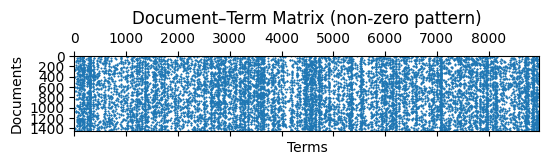

In [15]:
plt.figure(figsize=(6, 6))
plt.spy(x_test_BoW, markersize=0.5)  # don’t render all points large!
plt.title("Document–Term Matrix (non-zero pattern)")
plt.xlabel("Terms")
plt.ylabel("Documents")
plt.show()

In [16]:
from sklearn.naive_bayes import MultinomialNB

# Train the model
naive_bayes = MultinomialNB()
naive_bayes_fit = naive_bayes.fit(x_train_BoW, y_train)

In [17]:
from sklearn.metrics import confusion_matrix, balanced_accuracy_score

# Make predictions
train_predict = naive_bayes_fit.predict(x_train_BoW)
test_predict = naive_bayes_fit.predict(x_test_BoW)

def get_scores(y_real, predict):
  ba_train = balanced_accuracy_score(y_real, predict)
  return ba_train

train_scores = get_scores(y_train, train_predict)
test_scores = get_scores(y_test, test_predict)

In [18]:
print("Accuracy of Train set = {0:.2%}".format(train_scores))
print("Accuracy of Test set = {0:.2%}".format(test_scores))

Accuracy of Train set = 97.79%
Accuracy of Test set = 94.27%


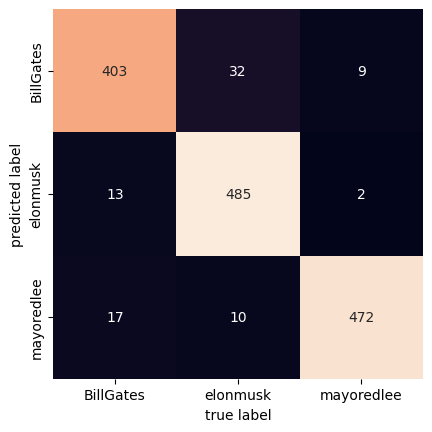

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

mat = confusion_matrix(y_test, test_predict)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=naive_bayes_fit.classes_, yticklabels=naive_bayes_fit.classes_)
plt.xlabel('true label')
plt.ylabel('predicted label');

### 3. TF-IDF approach

Reflects how important a word is to a document in a collection or corpus. TF-IDF assigns a weight to each word in a document based on two factors:
1.  **Term Frequency (TF)**: This measures how frequently a term appears in a document. A higher TF means the word is more important within that specific document.
   <br>
    $TF(t, d) = \frac{\text{Number of times term t appears in document d}}{\text{Total number of terms in document d}}$



2.  **Inverse Document Frequency (IDF)**: This measures how unique or rare a term is across the entire corpus. Words that appear in many documents (like common stop words) will have a low IDF, while rare words will have a high IDF.
   <br>
    $IDF(t, D) = \log\left(\frac{\text{Total number of documents D}}{\text{Number of documents containing term t}}\right)$
   <br>

**TF-IDF Score**: The final TF-IDF score is the product of TF and IDF:
$TFIDF(t, d, D) = TF(t, d) \times IDF(t, D)$

### Differences between BoW vs TF-IDF:
*   **Importance of Words**: Unlike BoW, which simply counts word occurrences, TF-IDF weighs words by their relevance. Words that are common across all documents (e.g., stop words) get penalized, while words that are unique to a few documents get higher scores.
*   **Semantic Clue**: While still not understanding context in a deep way, TF-IDF provides a better proxy for the semantic importance of a word compared to raw frequency counts. It helps identify words that are truly descriptive of a document.
*   **Vector Representation**: Both BoW and TF-IDF create vector representations of text. However, BoW vectors contain raw counts or binary presence, while TF-IDF vectors contain weighted scores.

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_tfidf = TfidfVectorizer(strip_accents = 'ascii')

# Fit the vectorizer on the x_train data and transform train and test
vectorizer_tdfidf_fit = vectorizer_tfidf.fit(x_train)
x_train_tfidf = vectorizer_tdfidf_fit.fit_transform(x_train)
x_test_tfidf = vectorizer_tdfidf_fit.transform(x_test)

print(type(x_train_tfidf)) # sparse matrix
print('Training data set shape:', x_train_tfidf.shape)
print('Testing data set shape:', x_test_tfidf.shape)

<class 'scipy.sparse._csr.csr_matrix'>
Training data set shape: (5769, 8982)
Testing data set shape: (1443, 8982)


In [21]:
x_test_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 12092 stored elements and shape (1443, 8982)>

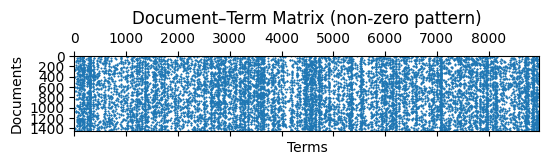

In [22]:
plt.figure(figsize=(6, 6))
plt.spy(x_test_tfidf, markersize=0.5)  # don’t render all points large!
plt.title("Document–Term Matrix (non-zero pattern)")
plt.xlabel("Terms")
plt.ylabel("Documents")
plt.show()

In [23]:
naive_bayes = MultinomialNB()
naive_bayes_fit = naive_bayes.fit(x_train_tfidf, y_train)

train_predict = naive_bayes_fit.predict(x_train_tfidf)
test_predict = naive_bayes_fit.predict(x_test_tfidf)

train_scores = get_scores(y_train, train_predict)
test_scores = get_scores(y_test, test_predict)

def print_scores(scores):
  return f"Balanced Accuracy: {scores}"

print("## Train Accuracy")
print(print_scores(f"{train_scores:.2%}"))
print("\n## Test Accuracy")
print(print_scores(f"{test_scores:.2%}"))

## Train Accuracy
Balanced Accuracy: 97.85%

## Test Accuracy
Balanced Accuracy: 93.86%


Confusion Matrix


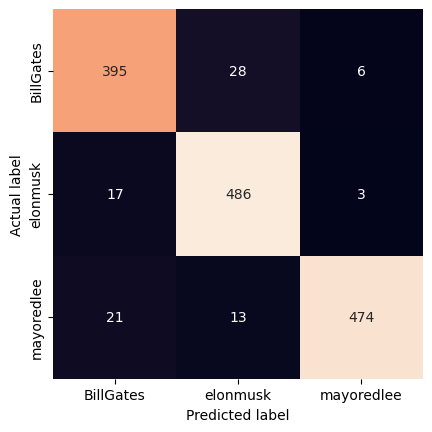

In [24]:
print("Confusion Matrix")
mat = confusion_matrix(y_test, test_predict)

sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=naive_bayes_fit.classes_, yticklabels=naive_bayes_fit.classes_)
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.show()

We can browse the prior probabilities. They seem balanced.

In [25]:
print("\n## Prior Probabilities of each class")
# Prior probabilities of each class
for class_name, prob in zip(naive_bayes_fit.classes_, naive_bayes_fit.class_log_prior_):
    print(f"Class {class_name}: {np.exp(prob):.4f}")


## Prior Probabilities of each class
Class BillGates: 0.2867
Class elonmusk: 0.3729
Class mayoredlee: 0.3404


We can go through some tweets and see each class probability.

In [ ]:
# Select one test tweet (e.g., the first one in x_test_text)
sample_tweet_index = 3
sample_tweet_text = x_test.iloc[sample_tweet_index]

# Transform the sample tweet using the fitted TF-IDF vectorizer
sample_tweet_transformed = vectorizer_tdfidf_fit.transform([sample_tweet_text])

# Predict probabilities for the sample tweet
predicted_probabilities = naive_bayes_fit.predict_proba(sample_tweet_transformed)

print(f"Sample Test Tweet: {sample_tweet_text}")
print(f"True Author: {y_test.iloc[sample_tweet_index]}")
print("\nPredicted Probabilities for each class:")
for class_name, prob in zip(naive_bayes_fit.classes_, predicted_probabilities[0]):
    print(f"Class {class_name}: {prob:.4f}")

Sample Test Tweet: today young san franciscans attend youth job plus get help w resume improve interview skil
True Author: mayoredlee

Predicted Probabilities for each class:
Class BillGates: 0.2200
Class elonmusk: 0.0773
Class mayoredlee: 0.7027


And finally, we can add our own tweets and have them classified.

In [ ]:
new_sentence = "I am working on the next big rocket launch. It will be amazing!"

# Preprocess the new sentence using the same functions
cleaned_sentence = cleantext(new_sentence)
tokenized_sentence = tokenizer.tokenize(cleaned_sentence)
stopwords_removed_sentence = [item for item in tokenized_sentence if item not in stop]
lemmatized_sentence = lemmatize_tokens(stopwords_removed_sentence)
final_preprocessed_sentence = ' '.join(lemmatized_sentence)

# Transform the preprocessed sentence using the fitted TF-IDF vectorizer
new_sentence_transformed = vectorizer_tfidf.transform([final_preprocessed_sentence])

# Predict probabilities for the new sentence
predicted_probabilities_new = naive_bayes_fit.predict_proba(new_sentence_transformed)
predicted_author_new = naive_bayes_fit.predict(new_sentence_transformed)[0]

print(f"Input Sentence: {new_sentence}")
print(f"Predicted Author: {predicted_author_new}")
print("\nPredicted Probabilities for each class:")
for class_name, prob in zip(naive_bayes_fit.classes_, predicted_probabilities_new[0]):
    print(f"Class {class_name}: {prob:.4f}")

Input Sentence: I am working on the next big rocket launch. It will be amazing!
Predicted Author: elonmusk

Predicted Probabilities for each class:
Class BillGates: 0.1407
Class elonmusk: 0.8238
Class mayoredlee: 0.0355
